In [2]:
!nvidia-smi
!ls -lah /content/FineTuning
!ls -lah /content/FineTuning/data/qwen

Mon May 25 06:59:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [7]:
!pip -q install -U "transformers>=5.0.0" accelerate datasets peft qwen-vl-utils jiwer pillow pandas openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 159.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 69.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
das

In [6]:
pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [4]:
%cd /content
!python /content/FineTuning/Qwen3VL_LoRA/train_qwen3vl_lora.py \
  --train-limit 2 \
  --val-limit 2 \
  --dry-run

/content
preprocessor_config.json: 100% 390/390 [00:00<00:00, 1.72MB/s]
chat_template.json: 5.50kB [00:00, 16.8MB/s]
config.json: 1.50kB [00:00, 4.84MB/s]
tokenizer_config.json: 10.9kB [00:00, 28.8MB/s]
vocab.json: 2.78MB [00:00, 40.7MB/s]
merges.txt: 1.67MB [00:00, 117MB/s]
tokenizer.json: 7.03MB [00:00, 146MB/s]
video_preprocessor_config.json: 100% 385/385 [00:00<00:00, 2.18MB/s]
{'input_ids': (2, 506), 'attention_mask': (2, 506), 'mm_token_type_ids': (2, 506), 'pixel_values': (3648, 1536), 'image_grid_thw': (2, 3), 'labels': (2, 506)}
train=2 val=2


In [7]:
!python /content/FineTuning/Qwen3VL_LoRA/train_qwen3vl_lora.py \
  --train-json /content/FineTuning/data/qwen/train.json \
  --val-json /content/FineTuning/data/qwen/val.json \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_standard \
  --epochs 3 \
  --batch-size 1 \
  --grad-accum 8 \
  --gradient-checkpointing

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:01<00:00, 498.77it/s]
trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
  0% 0/693 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': '0.5151', 'grad_norm': '1.184', 'learning_rate': '8.571e-05', 'epoch': '0.04338'}
{'loss': '0.3613', 'grad_norm': '0.9394', 'learning_rate': '0.000181', 'epoch': '0.08677'}
{'loss': '0.2774', 'grad_norm': '1.508', 'learning_rate': '0.0001976', 'epoch': '0.1302'}
{'loss': '0.153', 'grad_norm': '0.8369', 'learning_rate': '0.0001946', 'epoch': '0.1735'}
{'loss': '0.1554', 'grad_norm': '1.055', 'learning_rate': '0.0001917', 'epoch': '0.2169'}
{'loss': '0.1101', 'grad_norm': '0.4628', 'learning_rate'

In [8]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_standard \
  --test-json /content/FineTuning/data/qwen/test.json \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard \
  --run-name qwen3vl_lora_standard

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 957.05it/s] 
processed 25/241
processed 50/241
processed 75/241
processed 100/241
processed 125/241
processed 150/241
processed 175/241
processed 200/241
processed 225/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard/qwen3vl_lora_standard_summary.csv


In [9]:
import pandas as pd
pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard/qwen3vl_lora_standard_summary.csv')

,model_id,dataset,source_dataset,preprocessing_variant,samples,cer_mean,cer_median,corpus_cer,wer_mean,wer_median,...,word_substitutions,word_insertions,word_deletions,correct_recognized_words,inference_seconds_total,inference_seconds_mean,inference_seconds_median,rss_after_mb_max,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,qwen3vl_lora_standard,polish_forms_test,polish_forms,native,241,0.011807,0.0,0.012022,0.04546,0.0,...,68,3,4,1651,364.317723,1.511692,1.489565,NaN,4258.48584,4348.0


In [1]:
import pandas as pd

group = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard/qwen3vl_lora_standard_group_summary.csv')
group[['group', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,dysgrafia,46,0.018591,0.063636,0.989726,0.936364
1,inne,36,0.017891,0.069388,0.982109,0.938776
2,nie,159,0.008847,0.032230,0.992979,0.968641


In [2]:
pred = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard/qwen3vl_lora_standard_predictions.csv')
pred[pred['cer'] > 0][['sample_id', 'group', 'reference', 'prediction', 'cer', 'wer']].head(20)

,sample_id,group,reference,prediction,cer,wer
1,014_p01_A_l02,nie,"Mężny bądź, chroń pułk twój i sześć flag","Mężny bądźś, chroń pułk twój i sześć flag",0.025000,0.125000
17,020_p01_A_l02,nie,"Mężny bądź, chroń pułk twój i sześć flag",Mężny bądź chroń pułk twój i sześć flag,0.025000,0.125000
25,037_p01_B_l02,nie,Mieć pół miliona i nie mieć pół miliona — to c...,Mieć pół miliona i nie mieć pół miliona — to c...,0.017544,0.083333
33,061_p01_C_l02,dysgrafia,ID: A-204; status=OK; temp=23.5°C,A-204; status=OK; temp=23.5°C,0.121212,0.250000
36,061_p01_C_l05,dysgrafia,O 21:30 rozpoczęło się ważne spotkanie zespołu,O 21:30 rozpoczęło się ważne spotkanie zespołu.,0.021739,0.142857
50,072_p01_B_l03,nie,„Bóg nie gra w kości” — powiedział kiedyś Einsein,„Bóg nie gra w kości” — powiedział kiedyś Eins...,0.020408,0.111111
52,072_p01_B_l05,nie,Spotkanie rozpoczeło się 18:45 w sali nr. 3,Spotkanie rozpoczeło się o 18:45 w sali nr. 3,0.046512,0.125000
60,083_p01_C_l05,nie,O 21:30 rozpoczęło się ważne spotkanie zespolu.,O 21:30 rozpoczęło się ważne spotkanie zespołu.,0.021277,0.142857
62,083_p01_C_l08,nie,ANALIZA WYKAZAŁA SKUIECZNOSC 87%,ANALIZA WYKAZAŁA SKUTECZNOŚĆ 87%,0.093750,0.250000
68,089_p01_A_l07,nie,Żółw powoli przeszedl przez krętą ścieżkę w wi...,Żółw powoli przeszedł przez krętą ścieżkę w wi...,0.016667,0.111111


In [4]:
!rm -rf /content/FineTuning /content/ocr_benchmark_utils.py
!unzip -q /content/drive/MyDrive/Magisterka/polish_forms_qwen3vl_lora_colab.zip -d /content
!ls -lah /content/FineTuning/Qwen3VL_LoRA

total 28K
drwxr-xr-x 2 root root 4.0K May 25 12:01 .
drwxr-xr-x 5 root root 4.0K May 25 12:01 ..
-rw-r--r-- 1 root root 7.0K May 25 08:25 evaluate_qwen3vl_lora.py
-rw-r--r-- 1 root root  783 May 25 08:26 README.md
-rw-r--r-- 1 root root 7.8K May 25 08:28 train_qwen3vl_lora.py


In [8]:
!python /content/FineTuning/Qwen3VL_LoRA/train_qwen3vl_lora.py \
  --train-json /content/FineTuning/data/qwen/train_dysgraphia_oversampled.json \
  --val-json /content/FineTuning/data/qwen/val.json \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled \
  --epochs 3 \
  --batch-size 1 \
  --grad-accum 8 \
  --gradient-checkpointing

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:01<00:00, 497.10it/s]
trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
  0% 0/1002 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': '0.715', 'grad_norm': '1.392', 'learning_rate': '5.806e-05', 'epoch': '0.02999'}
{'loss': '0.4069', 'grad_norm': '0.9079', 'learning_rate': '0.0001226', 'epoch': '0.05997'}
{'loss': '0.4014', 'grad_norm': '1.136', 'learning_rate': '0.0001871', 'epoch': '0.08996'}
{'loss': '0.2297', 'grad_norm': '0.9437', 'learning_rate': '0.0001984', 'epoch': '0.1199'}
{'loss': '0.1753', 'grad_norm': '0.901', 'learning_rate': '0.0001963', 'epoch': '0.1499'}
{'loss': '0.2498', 'grad_norm': '2.096', 'learning_rat

In [9]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled \
  --test-json /content/FineTuning/data/qwen/test.json \
  --data-root /content/FineTuning/data \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled \
  --run-name qwen3vl_lora_dysgraphia_oversampled

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1003.50it/s]
processed 25/241
processed 50/241
processed 75/241
processed 100/241
processed 125/241
processed 150/241
processed 175/241
processed 200/241
processed 225/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled/qwen3vl_lora_dysgraphia_oversampled_summary.csv


In [10]:
import pandas as pd
pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled/qwen3vl_lora_dysgraphia_oversampled_summary.csv')

,model_id,dataset,source_dataset,preprocessing_variant,samples,cer_mean,cer_median,corpus_cer,wer_mean,wer_median,...,word_substitutions,word_insertions,word_deletions,correct_recognized_words,inference_seconds_total,inference_seconds_mean,inference_seconds_median,rss_after_mb_max,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,polish_forms,native,241,0.007969,0.0,0.008015,0.039791,0.0,...,59,3,2,1662,360.285914,1.494962,1.464538,NaN,4258.48584,4348.0


In [11]:
import pandas as pd

g = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled/qwen3vl_lora_dysgraphia_oversampled_group_summary.csv')
g[['group', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,dysgrafia,46,0.013699,0.063636,0.991194,0.936364
1,inne,36,0.017891,0.073469,0.984026,0.934694
2,nie,159,0.004213,0.021777,0.996911,0.979094


In [12]:
std = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard/qwen3vl_lora_standard_group_summary.csv')
over = pd.read_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled/qwen3vl_lora_dysgraphia_oversampled_group_summary.csv')

std['run'] = 'standard'
over['run'] = 'dysgraphia_oversampled'

cmp = pd.concat([std, over])
cmp[['run', 'group', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,run,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,standard,dysgrafia,46,0.018591,0.063636,0.989726,0.936364
1,standard,inne,36,0.017891,0.069388,0.982109,0.938776
2,standard,nie,159,0.008847,0.032230,0.992979,0.968641
0,dysgraphia_oversampled,dysgrafia,46,0.013699,0.063636,0.991194,0.936364
1,dysgraphia_oversampled,inne,36,0.017891,0.073469,0.984026,0.934694
2,dysgraphia_oversampled,nie,159,0.004213,0.021777,0.996911,0.979094


In [13]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

run_dir = '/content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled'
state_files = glob.glob(run_dir + '/**/trainer_state.json', recursive=True)

logs = []
for path in state_files:
    with open(path, encoding='utf-8') as f:
        state = json.load(f)
    for row in state.get('log_history', []):
        row = dict(row)
        row['state_file'] = path
        logs.append(row)

log_df = pd.DataFrame(logs).drop_duplicates()
log_df.to_csv(run_dir + '/training_log_history.csv', index=False)
log_df.tail()

,epoch,grad_norm,learning_rate,loss,step,state_file,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
315,2.935532,0.691826,4.737384e-06,0.012638,980,/content/drive/MyDrive/Magisterka/outputs/qwen...,NaN,NaN,NaN,NaN
316,2.965517,0.025396,2.677652e-06,0.016171,990,/content/drive/MyDrive/Magisterka/outputs/qwen...,NaN,NaN,NaN,NaN
317,2.995502,0.604422,6.179197e-07,0.010757,1000,/content/drive/MyDrive/Magisterka/outputs/qwen...,NaN,NaN,NaN,NaN
318,2.995502,NaN,NaN,NaN,1000,/content/drive/MyDrive/Magisterka/outputs/qwen...,0.058747,38.5331,5.917,5.917
319,3.000000,NaN,NaN,NaN,1002,/content/drive/MyDrive/Magisterka/outputs/qwen...,0.058777,39.2975,5.802,5.802


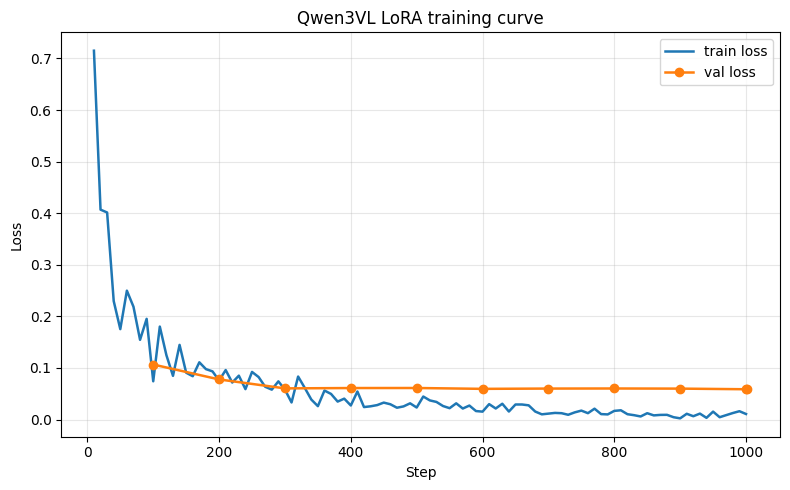

In [15]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

run_dir = '/content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled'

state_files = glob.glob(run_dir + '/**/trainer_state.json', recursive=True)

logs = []
for path in state_files:
    with open(path, encoding='utf-8') as f:
        state = json.load(f)
    for row in state.get('log_history', []):
        row = dict(row)
        logs.append(row)

log_df = pd.DataFrame(logs)

# osobno train i val, sortowanie + usunięcie duplikatów
train = (
    log_df.dropna(subset=['loss'])
    .sort_values('step')
    .drop_duplicates(subset=['step'], keep='last')
)

val = (
    log_df.dropna(subset=['eval_loss'])
    .sort_values('step')
    .drop_duplicates(subset=['step'], keep='last')
)

log_clean = pd.concat([
    train.assign(kind='train_loss'),
    val.assign(kind='val_loss')
], ignore_index=True)

log_clean.to_csv(run_dir + '/training_log_history_clean.csv', index=False)

plt.figure(figsize=(8,5))
plt.plot(train['step'], train['loss'], label='train loss', linewidth=1.8)
plt.plot(val['step'], val['eval_loss'], label='val loss', marker='o', linewidth=1.8)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Qwen3VL LoRA training curve')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(run_dir + '/training_loss_curve_clean.png', dpi=200)
plt.show()

In [16]:
cmp.to_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_standard_vs_oversampling_by_group.csv', index=False)

In [18]:
!unzip -o -q /content/drive/MyDrive/Magisterka/malaysian_qwen_external_validation_colab.zip -d /content
%cd /content
!pip -q install "transformers>=5.0.0" accelerate datasets peft qwen-vl-utils jiwer openpyxl

/content


In [19]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled \
  --test-json /content/FineTuning/malaysian_external_qwen/qwen/malaysian_auto_invert.json \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled_malaysian_auto_invert \
  --run-name qwen3vl_lora_dysgraphia_oversampled_malaysian_auto_invert

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1059.53it/s]
processed 25/424
processed 50/424
processed 75/424
processed 100/424
processed 125/424
processed 150/424
processed 175/424
processed 200/424
processed 225/424
processed 250/424
processed 275/424
processed 300/424
processed 325/424
processed 350/424
processed 375/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled_malaysian_auto_invert/qwen3vl_lora_dysgraphia_oversampled_malaysian_auto_invert_summary.csv


In [20]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_standard \
  --test-json /content/FineTuning/malaysian_external_qwen/qwen/malaysian_auto_invert.json \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard_malaysian_auto_invert \
  --run-name qwen3vl_lora_standard_malaysian_auto_invert

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1079.29it/s]
processed 25/424
processed 50/424
processed 75/424
processed 100/424
processed 125/424
processed 150/424
processed 175/424
processed 200/424
processed 225/424
processed 250/424
processed 275/424
processed 300/424
processed 325/424
processed 350/424
processed 375/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard_malaysian_auto_invert/qwen3vl_lora_standard_malaysian_auto_invert_summary.csv


In [21]:
import glob, pandas as pd

rows = []
for path in glob.glob('/content/drive/MyDrive/Magisterka/evaluation/*malaysian*/*_summary.csv'):
    df = pd.read_csv(path)
    rows.append(df)

summary = pd.concat(rows, ignore_index=True)
summary[['model_id', 'dataset', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,model_id,dataset,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,424,0.094934,0.248423,0.924521,0.766167
1,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,248,0.032418,0.106135,0.973390,0.898160
2,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,176,0.211542,0.504415,0.833366,0.528698
3,qwen3vl_lora_standard_malaysian_auto_invert,malaysian_auto_invert,424,0.084141,0.230284,0.934901,0.779574
4,qwen3vl_lora_standard_malaysian_auto_invert,malaysian_auto_invert,248,0.023654,0.086503,0.980465,0.917791
5,qwen3vl_lora_standard_malaysian_auto_invert,malaysian_auto_invert,176,0.196967,0.488962,0.849911,0.530905


In [22]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_standard \
  --test-json /content/FineTuning/malaysian_external_qwen/qwen/malaysian_raw.json \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard_malaysian_raw \
  --run-name qwen3vl_lora_standard_malaysian_raw

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1007.60it/s]
processed 25/424
processed 50/424
processed 75/424
processed 100/424
processed 125/424
processed 150/424
processed 175/424
processed 200/424
processed 225/424
processed 250/424
processed 275/424
processed 300/424
processed 325/424
processed 350/424
processed 375/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_standard_malaysian_raw/qwen3vl_lora_standard_malaysian_raw_summary.csv


In [23]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_dysgraphia_oversampled \
  --test-json /content/FineTuning/malaysian_external_qwen/qwen/malaysian_raw.json \
  --data-root /content/FineTuning/malaysian_external_qwen \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled_malaysian_raw \
  --run-name qwen3vl_lora_dysgraphia_oversampled_malaysian_raw

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 975.78it/s] 
processed 25/424
processed 50/424
processed 75/424
processed 100/424
processed 125/424
processed 150/424
processed 175/424
processed 200/424
processed 225/424
processed 250/424
processed 275/424
processed 300/424
processed 325/424
processed 350/424
processed 375/424
processed 400/424
processed 424/424
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_dysgraphia_oversampled_malaysian_raw/qwen3vl_lora_dysgraphia_oversampled_malaysian_raw_summary.csv


In [24]:
import glob, pandas as pd

rows = []
for path in glob.glob('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora*/*_summary.csv'):
    df = pd.read_csv(path)
    rows.append(df)

qwen_summary = pd.concat(rows, ignore_index=True)
qwen_summary[['model_id', 'dataset', 'preprocessing_variant', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,model_id,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,qwen3vl_lora_standard,polish_forms_test,native,241,0.012022,0.043529,0.990774,0.958212
1,qwen3vl_lora_standard,polish_forms_test,native,46,0.018591,0.063636,0.989726,0.936364
2,qwen3vl_lora_standard,polish_forms_test,native,36,0.017891,0.069388,0.982109,0.938776
3,qwen3vl_lora_standard,polish_forms_test,native,159,0.008847,0.032230,0.992979,0.968641
4,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,native,241,0.008015,0.037145,0.993942,0.964597
5,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,native,46,0.013699,0.063636,0.991194,0.936364
6,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,native,36,0.017891,0.073469,0.984026,0.934694
7,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,native,159,0.004213,0.021777,0.996911,0.979094
8,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,auto_invert,424,0.094934,0.248423,0.924521,0.766167
9,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,auto_invert,248,0.032418,0.106135,0.973390,0.898160


In [25]:
qwen_summary.to_csv('/content/drive/MyDrive/Magisterka/evaluation/qwen_finetuning_external_summary.csv', index=False)

In [26]:
overall = qwen_summary[
    ((qwen_summary['dataset'] == 'polish_forms_test') & (qwen_summary['samples'] == 241)) |
    ((qwen_summary['dataset'].str.contains('malaysian')) & (qwen_summary['samples'] == 424))
].copy()

overall[['model_id', 'dataset', 'preprocessing_variant', 'samples', 'corpus_cer', 'corpus_wer', 'corpus_cla', 'corpus_crw']]

,model_id,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,qwen3vl_lora_standard,polish_forms_test,native,241,0.012022,0.043529,0.990774,0.958212
4,qwen3vl_lora_dysgraphia_oversampled,polish_forms_test,native,241,0.008015,0.037145,0.993942,0.964597
8,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,auto_invert,424,0.094934,0.248423,0.924521,0.766167
11,qwen3vl_lora_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.084141,0.230284,0.934901,0.779574
14,qwen3vl_lora_standard_malaysian_raw,malaysian_raw,raw,424,0.080566,0.228707,0.939919,0.785095
17,qwen3vl_lora_dysgraphia_oversampled_malaysian_raw,malaysian_raw,raw,424,0.094384,0.253943,0.926720,0.761435


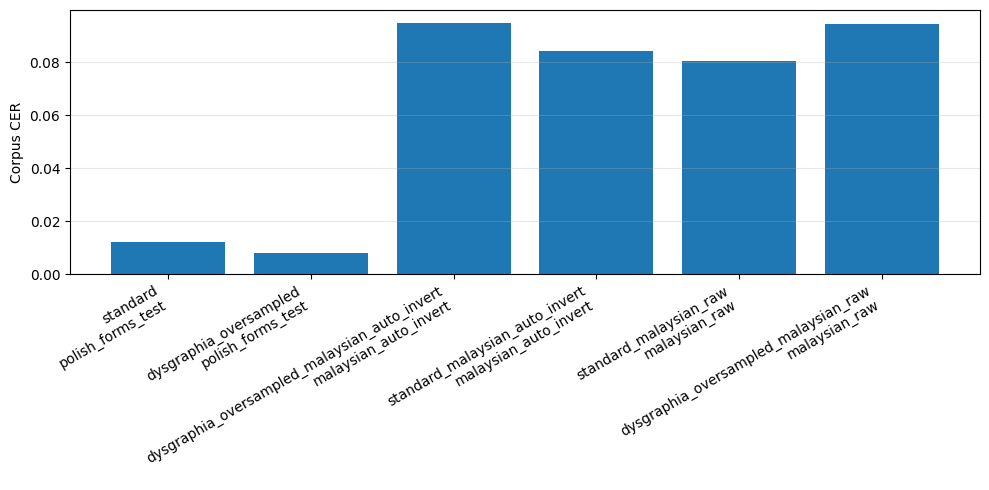

In [27]:
import matplotlib.pyplot as plt

plot_df = overall.copy()
plot_df['label'] = plot_df['model_id'].str.replace('qwen3vl_lora_', '', regex=False) + '\n' + plot_df['dataset']

plt.figure(figsize=(10,5))
plt.bar(plot_df['label'], plot_df['corpus_cer'])
plt.ylabel('Corpus CER')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Magisterka/evaluation/qwen_finetuning_cer_comparison.png', dpi=200)
plt.show()

In [28]:
!rm -rf /content/FineTuning /content/ocr_benchmark_utils.py
!unzip -q /content/drive/MyDrive/Magisterka/qwen_mixed_domain_colab.zip -d /content
%cd /content
!pip -q install "transformers>=5.0.0" accelerate datasets peft qwen-vl-utils jiwer openpyxl "pandas==2.2.2" "pillow<12"

unzip:  cannot find or open /content/drive/MyDrive/Magisterka/qwen_mixed_domain_colab.zip, /content/drive/MyDrive/Magisterka/qwen_mixed_domain_colab.zip.zip or /content/drive/MyDrive/Magisterka/qwen_mixed_domain_colab.zip.ZIP.
/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 125.2 MB/s eta 0:00:00


In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
!rm -rf /content/FineTuning /content/ocr_benchmark_utils.py
!unzip -q /content/drive/MyDrive/Magisterka/qwen_mixed_domain_colab.zip -d /content


In [38]:
!python /content/FineTuning/Qwen3VL_LoRA/train_qwen3vl_lora.py \
  --train-json /content/FineTuning/qwen_mixed_domain/qwen/mixed_train.json \
  --val-json /content/FineTuning/qwen_mixed_domain/qwen/mixed_val.json \
  --data-root /content/FineTuning/qwen_mixed_domain \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain \
  --epochs 2 \
  --batch-size 1 \
  --grad-accum 8 \
  --learning-rate 1e-4 \
  --lora-dropout 0.1 \
  --gradient-checkpointing

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:01<00:00, 499.95it/s]
trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
  0% 0/606 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': '0.7048', 'grad_norm': '2.122', 'learning_rate': '4.737e-05', 'epoch': '0.03309'}
{'loss': '0.4139', 'grad_norm': '1.699', 'learning_rate': '0.0001', 'epoch': '0.06617'}
{'loss': '0.3035', 'grad_norm': '1.027', 'learning_rate': '9.83e-05', 'epoch': '0.09926'}
{'loss': '0.2863', 'grad_norm': '1.556', 'learning_rate': '9.659e-05', 'epoch': '0.1323'}
{'loss': '0.1421', 'grad_norm': '1.028', 'learning_rate': '9.489e-05', 'epoch': '0.1654'}
{'loss': '0.166', 'grad_norm': '1.498', 'learning_rate': '9.

In [39]:
!python /content/FineTuning/Qwen3VL_LoRA/train_qwen3vl_lora.py \
  --train-json /content/FineTuning/qwen_mixed_domain/qwen/mixed_train.json \
  --val-json /content/FineTuning/qwen_mixed_domain/qwen/mixed_val.json \
  --data-root /content/FineTuning/qwen_mixed_domain \
  --output-dir /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain \
  --epochs 2 \
  --batch-size 1 \
  --grad-accum 8 \
  --learning-rate 1e-4 \
  --lora-dropout 0.1 \
  --gradient-checkpointing

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:01<00:00, 499.87it/s]
trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
  0% 0/606 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
{'loss': '0.7056', 'grad_norm': '2.025', 'learning_rate': '4.737e-05', 'epoch': '0.03309'}
{'loss': '0.4139', 'grad_norm': '1.643', 'learning_rate': '0.0001', 'epoch': '0.06617'}
{'loss': '0.3032', 'grad_norm': '1.001', 'learning_rate': '9.83e-05', 'epoch': '0.09926'}
{'loss': '0.2852', 'grad_norm': '1.479', 'learning_rate': '9.659e-05', 'epoch': '0.1323'}
{'loss': '0.1417', 'grad_norm': '1.036', 'learning_rate': '9.489e-05', 'epoch': '0.1654'}
{'loss': '0.1648', 'grad_norm': '1.474', 'learning_rate': '9

In [40]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain \
  --test-json /content/FineTuning/qwen_mixed_domain/qwen/polish_test.json \
  --data-root /content/FineTuning/qwen_mixed_domain \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_polish \
  --run-name qwen3vl_lora_mixed_domain_polish

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1005.35it/s]
processed 25/241
processed 50/241
processed 75/241
processed 100/241
processed 125/241
processed 150/241
processed 175/241
processed 200/241
processed 225/241
processed 241/241
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_polish/qwen3vl_lora_mixed_domain_polish_summary.csv


In [41]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain \
  --test-json /content/FineTuning/qwen_mixed_domain/qwen/malaysian_test_raw.json \
  --data-root /content/FineTuning/qwen_mixed_domain \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_malaysian_raw \
  --run-name qwen3vl_lora_mixed_domain_malaysian_raw

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 1070.05it/s]
processed 25/66
processed 50/66
processed 66/66
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_malaysian_raw/qwen3vl_lora_mixed_domain_malaysian_raw_summary.csv


In [42]:
!python /content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py \
  --adapter-path /content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain \
  --test-json /content/FineTuning/qwen_mixed_domain/qwen/malaysian_test_auto_invert.json \
  --data-root /content/FineTuning/qwen_mixed_domain \
  --output-dir /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_malaysian_auto_invert \
  --run-name qwen3vl_lora_mixed_domain_malaysian_auto_invert

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100% 625/625 [00:00<00:00, 994.25it/s] 
processed 25/66
processed 50/66
processed 66/66
/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain_malaysian_auto_invert/qwen3vl_lora_mixed_domain_malaysian_auto_invert_summary.csv


In [43]:
import glob
import pandas as pd

rows = []
for path in glob.glob('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain*/*_summary.csv'):
    df = pd.read_csv(path)
    df['path'] = path
    rows.append(df)

summary = pd.concat(rows, ignore_index=True)

cols = [
    'model_id',
    'dataset',
    'preprocessing_variant',
    'samples',
    'cer_mean',
    'corpus_cer',
    'wer_mean',
    'corpus_wer',
    'corpus_cla',
    'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max',
    'cuda_peak_reserved_mb_max'
]

summary[cols]

,model_id,dataset,preprocessing_variant,samples,cer_mean,corpus_cer,wer_mean,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,qwen3vl_lora_mixed_domain_polish,polish_forms_test,native,241,0.013589,0.013607,0.048875,0.045850,0.989376,0.957632,1.528989,4258.485840,4348.0
1,qwen3vl_lora_mixed_domain_polish,polish_forms_test,native,46,0.023749,0.022505,0.077243,0.072727,0.986791,0.927273,1.505868,4258.485840,4348.0
2,qwen3vl_lora_mixed_domain_polish,polish_forms_test,native,36,0.021761,0.023003,0.079751,0.081633,0.979553,0.934694,1.508883,4258.485352,4348.0
3,qwen3vl_lora_mixed_domain_polish,polish_forms_test,native,159,0.008800,0.008988,0.033678,0.030488,0.992276,0.971254,1.540230,4258.485840,4348.0
4,qwen3vl_lora_mixed_domain_malaysian_raw,malaysian_raw,raw,66,0.014446,0.013004,0.036869,0.031008,0.992825,0.971576,0.891785,4268.003418,4346.0
5,qwen3vl_lora_mixed_domain_malaysian_raw,malaysian_raw,raw,37,0.001689,0.000774,0.009009,0.004444,1.000000,0.995556,0.929465,4268.003418,4346.0
6,qwen3vl_lora_mixed_domain_malaysian_raw,malaysian_raw,raw,29,0.030722,0.029851,0.072414,0.067901,0.982942,0.938272,0.843712,4188.020508,4346.0
7,qwen3vl_lora_mixed_domain_malaysian_auto_invert,malaysian_auto_invert,auto_invert,66,0.011097,0.010762,0.028595,0.025840,0.993722,0.976744,0.881618,4268.003418,4346.0
8,qwen3vl_lora_mixed_domain_malaysian_auto_invert,malaysian_auto_invert,auto_invert,37,0.002709,0.002322,0.012012,0.008889,0.998452,0.991111,0.918127,4268.003418,4346.0
9,qwen3vl_lora_mixed_domain_malaysian_auto_invert,malaysian_auto_invert,auto_invert,29,0.021800,0.022388,0.049754,0.049383,0.987207,0.956790,0.835038,4188.020508,4346.0


In [44]:
rows = []
for path in glob.glob('/content/drive/MyDrive/Magisterka/evaluation/qwen3vl_lora_mixed_domain*/*_group_summary.csv'):
    df = pd.read_csv(path)
    df['run'] = path.split('/')[-2]
    rows.append(df)

groups = pd.concat(rows, ignore_index=True)

cols = [
    'run',
    'group',
    'samples',
    'corpus_cer',
    'corpus_wer',
    'corpus_cla',
    'corpus_crw'
]

groups[cols]

,run,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,qwen3vl_lora_mixed_domain_polish,dysgrafia,46,0.022505,0.072727,0.986791,0.927273
1,qwen3vl_lora_mixed_domain_polish,inne,36,0.023003,0.081633,0.979553,0.934694
2,qwen3vl_lora_mixed_domain_polish,nie,159,0.008988,0.030488,0.992276,0.971254
3,qwen3vl_lora_mixed_domain_malaysian_raw,LPD,37,0.000774,0.004444,1.000000,0.995556
4,qwen3vl_lora_mixed_domain_malaysian_raw,PD,29,0.029851,0.067901,0.982942,0.938272
5,qwen3vl_lora_mixed_domain_malaysian_auto_invert,LPD,37,0.002322,0.008889,0.998452,0.991111
6,qwen3vl_lora_mixed_domain_malaysian_auto_invert,PD,29,0.022388,0.049383,0.987207,0.956790


In [46]:
import json
import pandas as pd
from pathlib import Path

state_path = Path('/content/drive/MyDrive/Magisterka/outputs/qwen3vl_lora_mixed_domain/checkpoint-600/trainer_state.json')
state = json.loads(state_path.read_text())

logs = pd.DataFrame(state['log_history'])
logs[['step', 'loss', 'eval_loss', 'learning_rate', 'epoch']].dropna(how='all')

,step,loss,eval_loss,learning_rate,epoch
0,10,0.705602,NaN,0.000047,0.033085
1,20,0.413894,NaN,0.000100,0.066170
2,30,0.303196,NaN,0.000098,0.099256
3,40,0.285167,NaN,0.000097,0.132341
4,50,0.141735,NaN,0.000095,0.165426
...,...,...,...,...,...
61,570,0.069471,NaN,0.000006,1.883375
62,580,0.034578,NaN,0.000005,1.916460
63,590,0.030925,NaN,0.000003,1.949545
64,600,0.027493,NaN,0.000001,1.982630


In [47]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

DRIVE = Path('/content/drive/MyDrive/Magisterka')
DATA_ROOT = Path('/content/FineTuning/qwen_mixed_domain')
EVAL_SCRIPT = Path('/content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py')

if not EVAL_SCRIPT.exists():
    raise FileNotFoundError("Brakuje evaluate_qwen3vl_lora.py. Najpierw rozpakuj qwen_mixed_domain_colab.zip do /content.")

if not DATA_ROOT.exists():
    raise FileNotFoundError("Brakuje /content/FineTuning/qwen_mixed_domain. Najpierw rozpakuj paczkę mixed-domain.")

adapters = {
    "qwen3vl_lora_standard_malaysian_heldout": DRIVE / "outputs/qwen3vl_lora_standard",
    "qwen3vl_lora_dysgraphia_oversampled_malaysian_heldout": DRIVE / "outputs/qwen3vl_lora_dysgraphia_oversampled",
    "qwen3vl_lora_mixed_domain_malaysian_heldout": DRIVE / "outputs/qwen3vl_lora_mixed_domain",
}

tests = {
    "raw": DATA_ROOT / "qwen/malaysian_test_raw.json",
    "auto_invert": DATA_ROOT / "qwen/malaysian_test_auto_invert.json",
}

for adapter_name, adapter_path in adapters.items():
    if not adapter_path.exists():
        print(f"Pomijam, nie znaleziono adaptera: {adapter_path}")
        continue

    for variant, test_json in tests.items():
        run_name = f"{adapter_name}_{variant}"
        output_dir = DRIVE / "evaluation" / run_name
        summary_path = output_dir / f"{run_name}_summary.csv"

        if summary_path.exists():
            print(f"Już istnieje, pomijam: {run_name}")
            continue

        cmd = [
            sys.executable,
            str(EVAL_SCRIPT),
            "--adapter-path", str(adapter_path),
            "--test-json", str(test_json),
            "--data-root", str(DATA_ROOT),
            "--output-dir", str(output_dir),
            "--run-name", run_name,
        ]

        print("Uruchamiam:", run_name)
        subprocess.run(cmd, check=True)

print("Gotowe.")

Uruchamiam: qwen3vl_lora_standard_malaysian_heldout_raw
Uruchamiam: qwen3vl_lora_standard_malaysian_heldout_auto_invert
Uruchamiam: qwen3vl_lora_dysgraphia_oversampled_malaysian_heldout_raw
Uruchamiam: qwen3vl_lora_dysgraphia_oversampled_malaysian_heldout_auto_invert
Uruchamiam: qwen3vl_lora_mixed_domain_malaysian_heldout_raw
Uruchamiam: qwen3vl_lora_mixed_domain_malaysian_heldout_auto_invert
Gotowe.


In [48]:
eval_root = DRIVE / "evaluation"

summary_paths = [
    p for p in eval_root.glob("qwen3vl_lora_*malaysian*/*_summary.csv")
    if not p.name.endswith("_group_summary.csv")
]

summaries = []
for path in summary_paths:
    df = pd.read_csv(path)
    df["run_dir"] = path.parent.name
    summaries.append(df)

overall = pd.concat(summaries, ignore_index=True)

cols = [
    "run_dir",
    "model_id",
    "dataset",
    "preprocessing_variant",
    "samples",
    "corpus_cer",
    "corpus_wer",
    "corpus_cla",
    "corpus_crw",
    "inference_seconds_mean",
    "cuda_peak_allocated_mb_max",
    "cuda_peak_reserved_mb_max",
]

overall = overall[cols].sort_values(["preprocessing_variant", "corpus_cer"])
overall

,run_dir,model_id,dataset,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
5,qwen3vl_lora_mixed_domain_malaysian_auto_invert,qwen3vl_lora_mixed_domain_malaysian_auto_invert,malaysian_auto_invert,auto_invert,66,0.010762,0.025840,0.993722,0.976744,0.881618,4268.003418,4346.0
11,qwen3vl_lora_mixed_domain_malaysian_heldout_au...,qwen3vl_lora_mixed_domain_malaysian_heldout_au...,malaysian_auto_invert,auto_invert,66,0.010762,0.025840,0.993722,0.976744,0.897173,4268.003418,4346.0
7,qwen3vl_lora_standard_malaysian_heldout_auto_i...,qwen3vl_lora_standard_malaysian_heldout_auto_i...,malaysian_auto_invert,auto_invert,66,0.057399,0.167959,0.956502,0.844961,0.920831,4268.003906,4346.0
9,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,auto_invert,66,0.068161,0.186047,0.946188,0.821705,0.899327,4268.003906,4346.0
1,qwen3vl_lora_standard_malaysian_auto_invert,qwen3vl_lora_standard_malaysian_auto_invert,malaysian_auto_invert,auto_invert,424,0.084141,0.230284,0.934901,0.779574,0.945874,4269.010254,4348.0
0,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,malaysian_auto_invert,auto_invert,424,0.094934,0.248423,0.924521,0.766167,0.960727,4269.010254,4348.0
4,qwen3vl_lora_mixed_domain_malaysian_raw,qwen3vl_lora_mixed_domain_malaysian_raw,malaysian_raw,raw,66,0.013004,0.031008,0.992825,0.971576,0.891785,4268.003418,4346.0
10,qwen3vl_lora_mixed_domain_malaysian_heldout_raw,qwen3vl_lora_mixed_domain_malaysian_heldout_raw,malaysian_raw,raw,66,0.013004,0.031008,0.992825,0.971576,0.867843,4268.003418,4346.0
6,qwen3vl_lora_standard_malaysian_heldout_raw,qwen3vl_lora_standard_malaysian_heldout_raw,malaysian_raw,raw,66,0.067265,0.180879,0.952018,0.837209,0.922561,4268.003906,4346.0
2,qwen3vl_lora_standard_malaysian_raw,qwen3vl_lora_standard_malaysian_raw,malaysian_raw,raw,424,0.080566,0.228707,0.939919,0.785095,0.936601,4269.010254,4346.0


In [49]:
group_paths = list(eval_root.glob("qwen3vl_lora_*malaysian*/*_group_summary.csv"))

groups = []
for path in group_paths:
    df = pd.read_csv(path)
    df["run_dir"] = path.parent.name
    groups.append(df)

groups = pd.concat(groups, ignore_index=True)

group_cols = [
    "run_dir",
    "group",
    "samples",
    "corpus_cer",
    "corpus_wer",
    "corpus_cla",
    "corpus_crw",
]

groups[group_cols].sort_values(["run_dir", "group"])

,run_dir,group,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
0,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,LPD,248,0.032418,0.106135,0.973390,0.898160
1,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,PD,176,0.211542,0.504415,0.833366,0.528698
18,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,LPD,37,0.018576,0.066667,0.988390,0.933333
19,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,PD,29,0.136461,0.351852,0.888060,0.666667
16,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,LPD,37,0.030186,0.102222,0.972910,0.902222
17,qwen3vl_lora_dysgraphia_oversampled_malaysian_...,PD,29,0.166311,0.382716,0.873134,0.617284
6,qwen3vl_lora_dysgraphia_oversampled_malaysian_raw,LPD,248,0.030729,0.109816,0.974657,0.893252
7,qwen3vl_lora_dysgraphia_oversampled_malaysian_raw,PD,176,0.213118,0.513245,0.837305,0.524283
10,qwen3vl_lora_mixed_domain_malaysian_auto_invert,LPD,37,0.002322,0.008889,0.998452,0.991111
11,qwen3vl_lora_mixed_domain_malaysian_auto_invert,PD,29,0.022388,0.049383,0.987207,0.956790


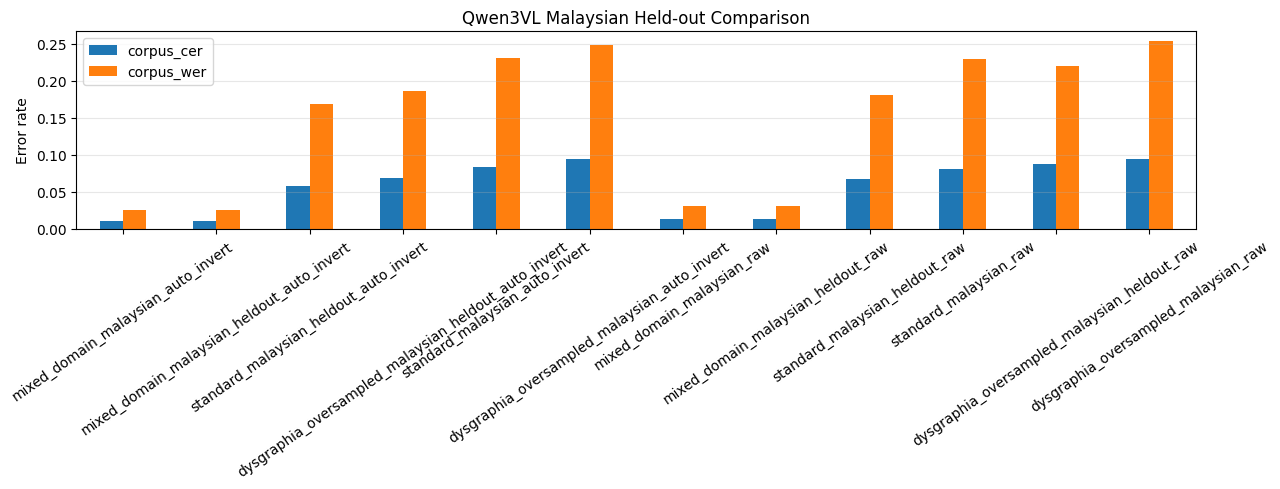

Zapisano: /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_malaysian_heldout_comparison.png


In [50]:
plot_df = overall.copy()
plot_df["label"] = plot_df["run_dir"].str.replace("qwen3vl_lora_", "", regex=False)

ax = plot_df.plot(
    x="label",
    y=["corpus_cer", "corpus_wer"],
    kind="bar",
    figsize=(13, 5),
    rot=35,
)

ax.set_ylabel("Error rate")
ax.set_xlabel("")
ax.set_title("Qwen3VL Malaysian Held-out Comparison")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

out_png = DRIVE / "evaluation/qwen3vl_malaysian_heldout_comparison.png"
plt.savefig(out_png, dpi=200)
plt.show()

print("Zapisano:", out_png)

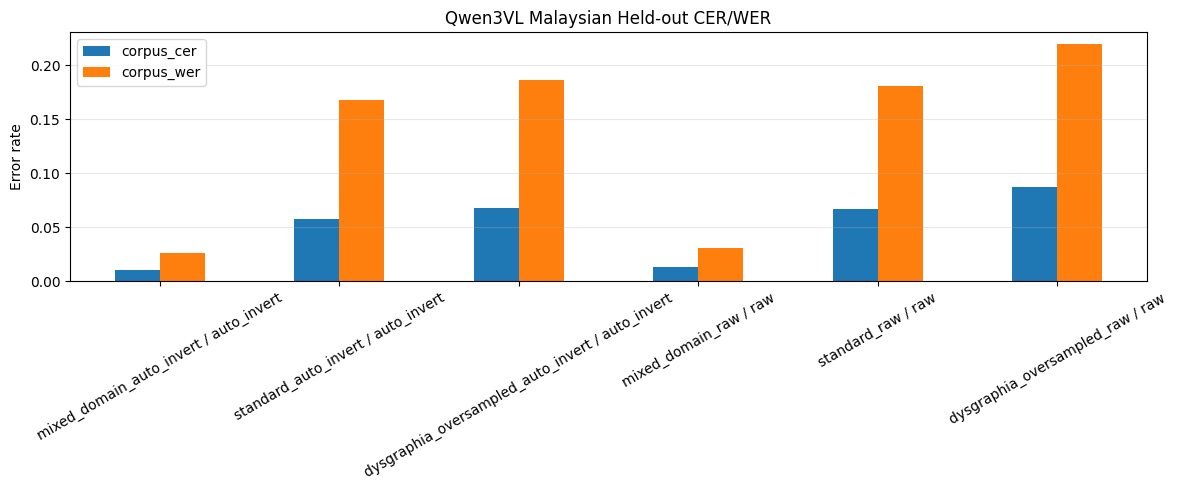

,model,preprocessing_variant,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw
5,mixed_domain_auto_invert,auto_invert,66,0.010762,0.025840,0.993722,0.976744
7,standard_auto_invert,auto_invert,66,0.057399,0.167959,0.956502,0.844961
9,dysgraphia_oversampled_auto_invert,auto_invert,66,0.068161,0.186047,0.946188,0.821705
4,mixed_domain_raw,raw,66,0.013004,0.031008,0.992825,0.971576
6,standard_raw,raw,66,0.067265,0.180879,0.952018,0.837209
8,dysgraphia_oversampled_raw,raw,66,0.087444,0.219638,0.930942,0.782946


In [51]:
clean = overall[
    (overall["samples"] == 66) &
    (
        overall["run_dir"].str.contains("heldout") |
        overall["run_dir"].str.contains("mixed_domain_malaysian_raw$") |
        overall["run_dir"].str.contains("mixed_domain_malaysian_auto_invert$")
    )
].copy()

clean = clean.drop_duplicates(
    subset=["dataset", "preprocessing_variant", "corpus_cer", "corpus_wer"]
)

clean["model"] = clean["run_dir"].str.replace("qwen3vl_lora_", "", regex=False)
clean["model"] = clean["model"].str.replace("_malaysian_heldout", "", regex=False)
clean["model"] = clean["model"].str.replace("_malaysian", "", regex=False)
clean["label"] = clean["model"] + " / " + clean["preprocessing_variant"]

clean = clean.sort_values(["preprocessing_variant", "corpus_cer"])

ax = clean.plot(
    x="label",
    y=["corpus_cer", "corpus_wer"],
    kind="bar",
    figsize=(12, 5),
    rot=30,
)

ax.set_ylabel("Error rate")
ax.set_xlabel("")
ax.set_title("Qwen3VL Malaysian Held-out CER/WER")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

out_png = DRIVE / "evaluation/qwen3vl_malaysian_heldout_clean_comparison.png"
plt.savefig(out_png, dpi=220)
plt.show()

clean[[
    "model",
    "preprocessing_variant",
    "samples",
    "corpus_cer",
    "corpus_wer",
    "corpus_cla",
    "corpus_crw",
]]

In [52]:
!unzip -oq /content/drive/MyDrive/Magisterka/qwen_iam_final_check_tools.zip -d /content
!pip -q install datasets

In [53]:
!python /content/FineTuning/prepare_qwen_iam_eval.py \
  --dataset-id Teklia/IAM-line \
  --split test \
  --limit 200 \
  --output-root /content/FineTuning/qwen_iam_eval

README.md: 2.14kB [00:00, 6.28MB/s]
data/train.parquet: 100% 167M/167M [00:04<00:00, 41.6MB/s]
data/validation.parquet: 100% 24.7M/24.7M [00:00<00:00, 30.5MB/s]
data/test.parquet: 100% 73.6M/73.6M [00:01<00:00, 72.8MB/s]
Generating train split: 100% 6482/6482 [00:00<00:00, 23634.36 examples/s]
Generating validation split: 100% 976/976 [00:00<00:00, 27797.22 examples/s]
Generating test split: 100% 2915/2915 [00:00<00:00, 28314.62 examples/s]
{
  "dataset_id": "Teklia/IAM-line",
  "split": "test",
  "limit": 200,
  "samples": 200,
  "json_path": "/content/FineTuning/qwen_iam_eval/qwen/iam_test_200.json",
  "images_dir": "/content/FineTuning/qwen_iam_eval/images"
}


In [54]:
from pathlib import Path
import subprocess, sys

DRIVE = Path('/content/drive/MyDrive/Magisterka')
DATA_ROOT = Path('/content/FineTuning/qwen_iam_eval')
TEST_JSON = DATA_ROOT / 'qwen/iam_test_200.json'
EVAL_SCRIPT = Path('/content/FineTuning/Qwen3VL_LoRA/evaluate_qwen3vl_lora.py')

adapters = {
    'qwen3vl_base_iam_200': None,
    'qwen3vl_lora_standard_iam_200': DRIVE / 'outputs/qwen3vl_lora_standard',
    'qwen3vl_lora_dysgraphia_oversampled_iam_200': DRIVE / 'outputs/qwen3vl_lora_dysgraphia_oversampled',
    'qwen3vl_lora_mixed_domain_iam_200': DRIVE / 'outputs/qwen3vl_lora_mixed_domain',
}

for run_name, adapter_path in adapters.items():
    output_dir = DRIVE / 'evaluation' / run_name
    if (output_dir / f'{run_name}_summary.csv').exists():
        print('Już istnieje:', run_name)
        continue

    cmd = [
        sys.executable, str(EVAL_SCRIPT),
        '--test-json', str(TEST_JSON),
        '--data-root', str(DATA_ROOT),
        '--output-dir', str(output_dir),
        '--run-name', run_name,
    ]

    if adapter_path is not None:
        cmd += ['--adapter-path', str(adapter_path)]

    print('Uruchamiam:', run_name)
    subprocess.run(cmd, check=True)

Uruchamiam: qwen3vl_base_iam_200
Uruchamiam: qwen3vl_lora_standard_iam_200
Uruchamiam: qwen3vl_lora_dysgraphia_oversampled_iam_200
Uruchamiam: qwen3vl_lora_mixed_domain_iam_200


,run_dir,samples,corpus_cer,corpus_wer,corpus_cla,corpus_crw,inference_seconds_mean,cuda_peak_allocated_mb_max,cuda_peak_reserved_mb_max
0,qwen3vl_base_iam_200,200,0.055659,0.314228,0.979335,0.688286,0.513185,4166.747559,4268.0
3,qwen3vl_lora_mixed_domain_iam_200,200,0.068847,0.336350,0.968224,0.669683,0.928669,4252.174316,4324.0
1,qwen3vl_lora_standard_iam_200,200,0.072378,0.346908,0.965524,0.656109,0.945669,4252.174316,4322.0
2,qwen3vl_lora_dysgraphia_oversampled_iam_200,200,0.081828,0.359980,0.955556,0.649070,0.967044,4252.174316,4324.0


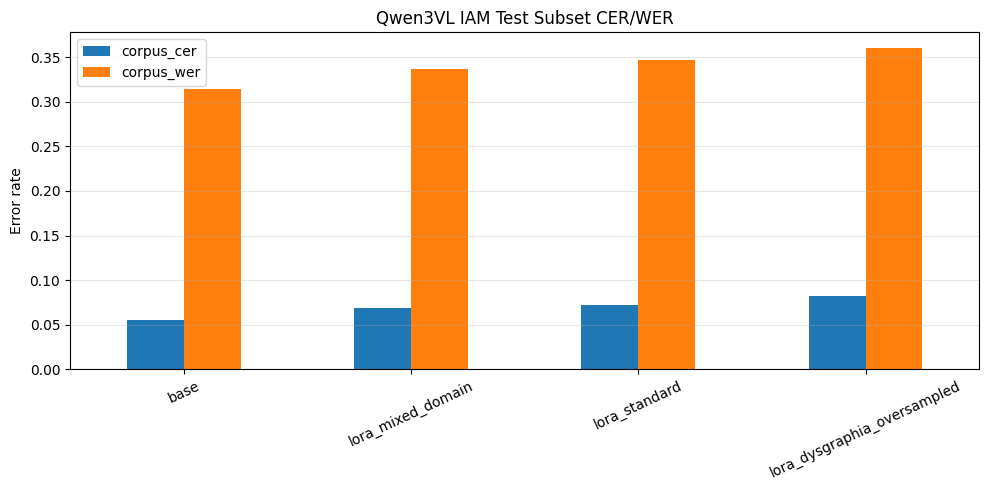

Zapisano: /content/drive/MyDrive/Magisterka/evaluation/qwen3vl_iam_200_comparison.png


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

paths = [
    p for p in (DRIVE / 'evaluation').glob('qwen3vl*_iam_200/*_summary.csv')
    if not p.name.endswith('_group_summary.csv')
]

iam = pd.concat([pd.read_csv(p).assign(run_dir=p.parent.name) for p in paths], ignore_index=True)
iam = iam[iam['dataset'].astype(str).str.startswith('iam_')].copy()

cols = [
    'run_dir', 'samples', 'corpus_cer', 'corpus_wer',
    'corpus_cla', 'corpus_crw',
    'inference_seconds_mean',
    'cuda_peak_allocated_mb_max',
    'cuda_peak_reserved_mb_max',
]

display(iam[cols].sort_values('corpus_cer'))

plot_df = iam[cols].sort_values('corpus_cer').copy()
plot_df['label'] = plot_df['run_dir'].str.replace('qwen3vl_', '', regex=False).str.replace('_iam_200', '', regex=False)

ax = plot_df.plot(x='label', y=['corpus_cer', 'corpus_wer'], kind='bar', figsize=(10, 5), rot=25)
ax.set_title('Qwen3VL IAM Test Subset CER/WER')
ax.set_xlabel('')
ax.set_ylabel('Error rate')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

out_png = DRIVE / 'evaluation/qwen3vl_iam_200_comparison.png'
plt.savefig(out_png, dpi=220)
plt.show()
print('Zapisano:', out_png)